In [2]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
PROJECT_NAME = "patch_icl_3d_eval"
DATASET = "totalseg_ct"  


dataset_configs = {
    "totalseg_ct": {"patch_icl": "wo9cwsts", "medverse": "pxukfrmy"},

}

runs = {k: {"wandb_name": v} for k, v in dataset_configs[DATASET].items()}
print(f"Dataset: {DATASET}")


wandb: Currently logged in as: tidiane to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset: totalseg_ct


In [3]:
for run_name, run_data in runs.items():
    artifact = api.artifact(f"tidiane/{PROJECT_NAME}/run-{run_data['wandb_name']}-cases:v0")
    artifact.download()
    table = artifact.get("cases.table.json")
    runs[run_name]["df"] = table.get_dataframe()

df_all = pd.concat([df.assign(Run=name) for name, data in runs.items() for df in [data["df"]]], ignore_index=True)
print(f"Loaded {len(df_all)} samples, {df_all['class'].nunique()} classes")

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Loaded 7794 samples, 117 classes


In [4]:
print(f"Loaded {len(df_all)} samples, {df_all['class'].nunique()} classes")

Loaded 7794 samples, 117 classes


In [6]:
import sys
sys.path.append("/home/dpxuser/dev/patch_icl/data")
from totalseg_classes import category_map_ct
classes = set(df_all['class'].unique())
df_all['category'] = df_all['class'].map(category_map_ct).fillna('Other')


In [7]:
# Category/Dataset summary
cat_stats = df_all.groupby(['Run', 'category'], observed=False)['dice'].agg(['mean', 'std', 'count']).reset_index()
cat_stats = cat_stats.sort_values(['Run', 'mean'], ascending=[True, False])

# Total samples per category (count from one run since both have same samples)
cat_samples = df_all[df_all['Run'] == 'patch_icl'].groupby('category', observed=False).size()

category_label = "DATASET" if DATASET == "medsegbench" else "CATEGORY"
print(f"DICE BY {category_label}\n" + "="*60)
for run_name, grp in cat_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    for _, row in grp.iterrows():
        print(f"{row['category']:<35} {row['mean']:.3f} +/- {row['std']:.3f}")

# Print total samples per category
print(f"\n" + "="*60)
print(f"SAMPLES PER {category_label}")
print("="*60)
for cat in cat_samples.index:
    print(f"{cat:<35} n={cat_samples[cat]}")
print(f"{'TOTAL':<35} n={cat_samples.sum()}")

# Compare PatchICL vs UniverSeg per category/dataset
cat_pivot = cat_stats.pivot(index='category', columns='Run', values='mean')
cat_pivot['diff'] = cat_pivot['patch_icl'] - cat_pivot['medverse']
cat_pivot = cat_pivot.sort_values('diff', ascending=False)

patch_wins = cat_pivot[cat_pivot['diff'] > 0]
univ_wins = cat_pivot[cat_pivot['diff'] < 0]

print(f"\n" + "="*60)
print(f"PATCHICL vs MEDVERSE BY {category_label}")
print("="*60)
print(f"\nPatchICL better on {len(patch_wins)}/{len(cat_pivot)} {category_label.lower()}s:")
for cat, row in patch_wins.iterrows():
    print(f"  {cat:<35} {row['patch_icl']:.3f} vs {row['medverse']:.3f} (Δ={row['diff']:+.3f})")

print(f"\nMedVerse better on {len(univ_wins)}/{len(cat_pivot)} {category_label.lower()}s:")
for cat, row in univ_wins.iterrows():
    print(f"  {cat:<35} {row['patch_icl']:.3f} vs {row['medverse']:.3f} (Δ={row['diff']:+.3f})")

DICE BY CATEGORY

--- medverse ---
Bones (Limbs/Shoulder/Pelvis)       0.255 +/- 0.302
Organs (Abd/Pelvis)                 0.244 +/- 0.359
Organs (Thorax/Head/Spine)          0.189 +/- 0.277
Muscles                             0.178 +/- 0.254
Vessels                             0.045 +/- 0.136
Bones (Spine)                       0.024 +/- 0.104
Bones (Ribs/Sternum)                0.023 +/- 0.079

--- patch_icl ---
Muscles                             0.488 +/- 0.240
Bones (Limbs/Shoulder/Pelvis)       0.481 +/- 0.273
Organs (Thorax/Head/Spine)          0.381 +/- 0.259
Organs (Abd/Pelvis)                 0.333 +/- 0.297
Bones (Spine)                       0.180 +/- 0.168
Vessels                             0.156 +/- 0.157
Bones (Ribs/Sternum)                0.047 +/- 0.113

SAMPLES PER CATEGORY
Bones (Limbs/Shoulder/Pelvis)       n=328
Bones (Ribs/Sternum)                n=952
Bones (Spine)                       n=743
Muscles                             n=378
Organs (Abd/Pelvis)         

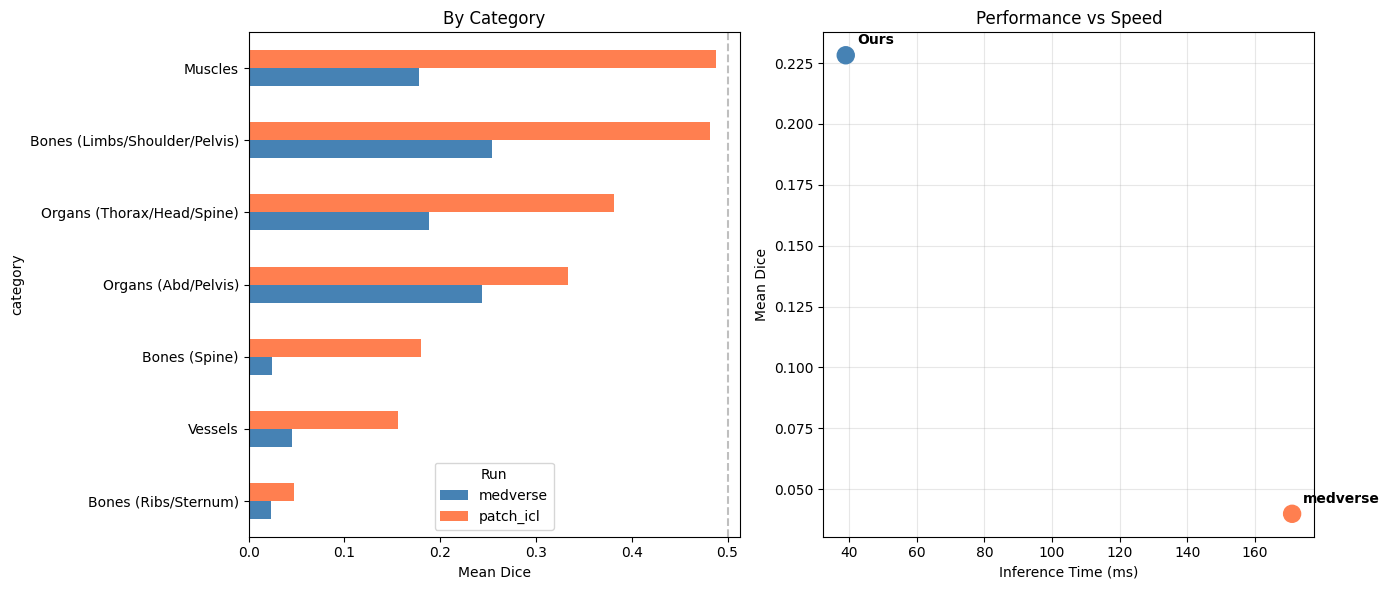

In [12]:
# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Category/Dataset comparison
category_label = "Dataset" if DATASET == "medsegbench" else "Category"
cat_pivot = cat_stats.pivot(index='category', columns='Run', values='mean').sort_values('patch_icl')
cat_pivot.plot(kind='barh', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_xlabel('Mean Dice')
axes[0].set_title(f'By {category_label}')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

methods = ['Ours', 'medverse']
dice_scores = [0.2282, 0.0399]
inference_times = [39, 171]
colors = ['steelblue', 'coral']

axes[1].scatter(inference_times, dice_scores, c=colors, s=150, zorder=3)

# Label each point
for i, method in enumerate(methods):
    axes[1].annotate(
        method,
        (inference_times[i], dice_scores[i]),
        xytext=(8, 8), textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

axes[1].set_xlabel('Inference Time (ms)')
axes[1].set_ylabel('Mean Dice')
axes[1].set_title('Performance vs Speed')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Overall statistics
print("=" * 60)
print("OVERALL STATISTICS")
print("=" * 60)
for run_name in ['patch_icl', 'medverse']:
    scores = df_all[df_all['Run'] == run_name]['dice']
    print(f"{run_name:<12}: {scores.mean():.3f} +/- {scores.std():.3f}")

OVERALL STATISTICS
patch_icl   : 0.242 +/- 0.261
medverse    : 0.110 +/- 0.236


In [8]:
# metrics of corresponding training run (patch_icl_3d_exps/runs/38s8cpnm/)
train_run = api.run(f"tidiane/patch_icl_3d_exps/38s8cpnm")


In [17]:
metrics = train_run.history()
metrics.columns


Index(['val/dice_fused_l2', 'val/pred/trachea', 'val/pred/gallbladder',
       'val/pred/heart', 'val/pred/rib_left_6', 'val/pred/autochthon_left',
       'val/pred/adrenal_gland_left', 'val/auroc', 'val/pred/small_bowel',
       'val/pred/lung_lower_lobe_left', 'train/pred_synth',
       'val/pred/thyroid_gland', 'val/pred/brain',
       'val/pred/atrial_appendage_left', '_step', 'val/pred/kidney_right',
       'val/pred/inferior_vena_cava', 'val/pred/gluteus_medius_right',
       'val/dice_fused_l0', 'train/loss', 'val/pred/kidney_left', 'val/dice',
       'val/loss', 'val/pred/brachiocephalic_trunk', 'val/pred/esophagus',
       'train/dice_l0', 'val/pred/scapula_left', 'val/pred/stomach',
       'val/pred/portal_vein_and_splenic_vein', 'val/pred/sacrum',
       'val/pred/humerus_left', 'val/pred/liver', 'val/pred/spinal_cord',
       'epoch', 'val/pred/pancreas', 'val/pred/vertebrae_T6', 'val/soft_dice',
       'train/loss_l0', 'val/dice_l1', 'val/pred/hip_right',
       'val/pred/

In [14]:
metrics.columns
# keep metrics with "dice" in their name
dice_metrics = metrics.filter(like='val/dice')

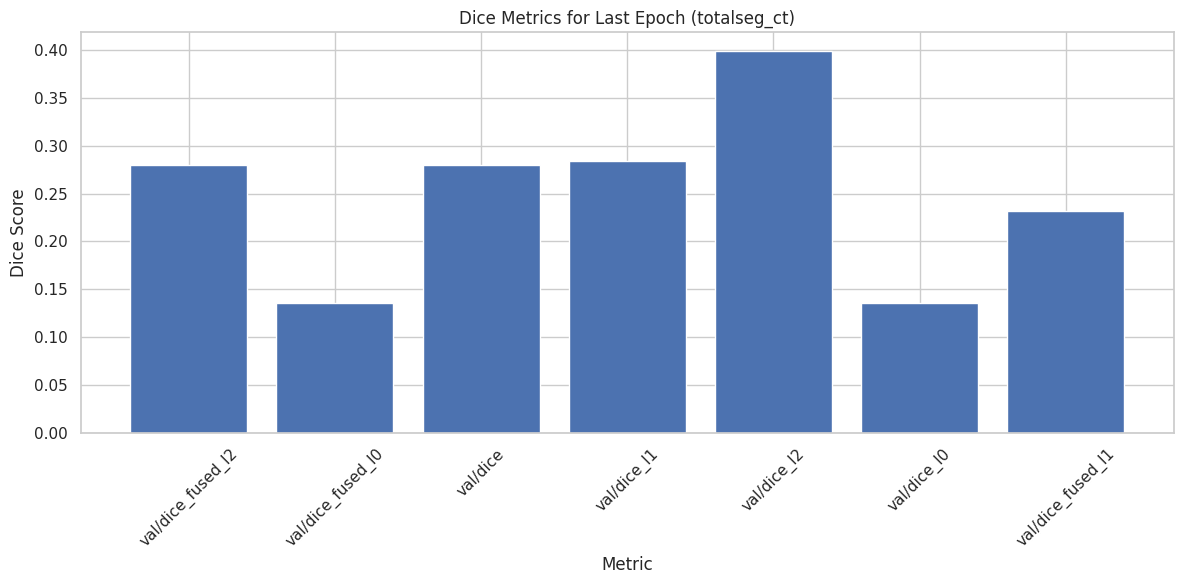

In [18]:
# plot dice_metrics values for last epoch   
plt.figure(figsize=(12, 6))
plt.bar(dice_metrics.columns, dice_metrics.iloc[-1])
plt.title(f'Dice Metrics for Last Epoch ({DATASET})')
plt.xlabel('Metric')
plt.ylabel('Dice Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()